In [46]:
# importing the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

### Load the Data

In [47]:
file_name = "/home/shanujya/cognifyz_internship_tasks/Dataset .csv"
df = pd.read_csv(file_name)

In [48]:
df.shape

(9551, 21)

In [49]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [51]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Missing values

In [52]:
df.isnull().sum()[df.isnull().sum()>0]

Cuisines    9
dtype: int64

So there are 9 missing values in the cuisines attributes as it is a tiny fraction of the dataset, the standard best practice is to delete these rows.

In [53]:
# Drop Rows where value is missing in cuisines feature
df_clean = df.dropna(subset=['Cuisines']).copy()

In [54]:
df_clean.isnull().sum()[df.isnull().sum()>0]

Cuisines    0
dtype: int64

In [55]:
### Checking any duplicate values
df_clean.duplicated().sum()

np.int64(0)

## Outlier Analysis

In [56]:
print("--- OUTLIER ANALYSIS ---")

# Function to calculate outliers using the Interquartile Range (IQR) method
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter for outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound, outliers

# 1. Analyze Votes Outliers
num_outliers_votes, lb_votes, ub_votes, votes_outliers = find_outliers(df, 'Votes')
print(f"\n1. VOTES:")
print(f"Number of outliers: {num_outliers_votes}")
print("Top 3 most voted restaurants (Outliers):")
print(votes_outliers[['Restaurant Name', 'City', 'Votes']].sort_values(by='Votes', ascending=False).head(3))

# 2. Analyze Cost Outliers
num_outliers_cost, lb_cost, ub_cost, cost_outliers = find_outliers(df, 'Average Cost for two')
print(f"\n2. AVERAGE COST:")
print(f"Number of outliers: {num_outliers_cost}")
print("Notice how different currencies cause cost outliers (e.g., IDR in Jakarta):")
print(cost_outliers[['Restaurant Name', 'City', 'Currency', 'Average Cost for two']].sort_values(by='Average Cost for two', ascending=False).head(3))

# 3. Analyze Rating Outliers
num_outliers_rating, lb_rating, ub_rating, rating_outliers = find_outliers(df, 'Aggregate rating')
print(f"\n3. AGGREGATE RATING:")
print(f"Number of rating outliers: {num_outliers_rating}")
print(f"Minimum outlier value is {rating_outliers['Aggregate rating'].min()}, which represents unrated restaurants.")

--- OUTLIER ANALYSIS ---

1. VOTES:
Number of outliers: 1126
Top 3 most voted restaurants (Outliers):
       Restaurant Name       City  Votes
728               Toit  Bangalore  10934
735           Truffles  Bangalore   9667
3994  Hauz Khas Social  New Delhi   7931

2. AVERAGE COST:
Number of outliers: 853
Notice how different currencies cause cost outliers (e.g., IDR in Jakarta):
               Restaurant Name     City                Currency  \
9283                      Skye  Jakarta  Indonesian Rupiah(IDR)   
9284  Satoo - Hotel Shangri-La  Jakarta  Indonesian Rupiah(IDR)   
9287                Sushi Masa  Jakarta  Indonesian Rupiah(IDR)   

      Average Cost for two  
9283                800000  
9284                800000  
9287                500000  

3. AGGREGATE RATING:
Number of rating outliers: 2148
Minimum outlier value is 0.0, which represents unrated restaurants.


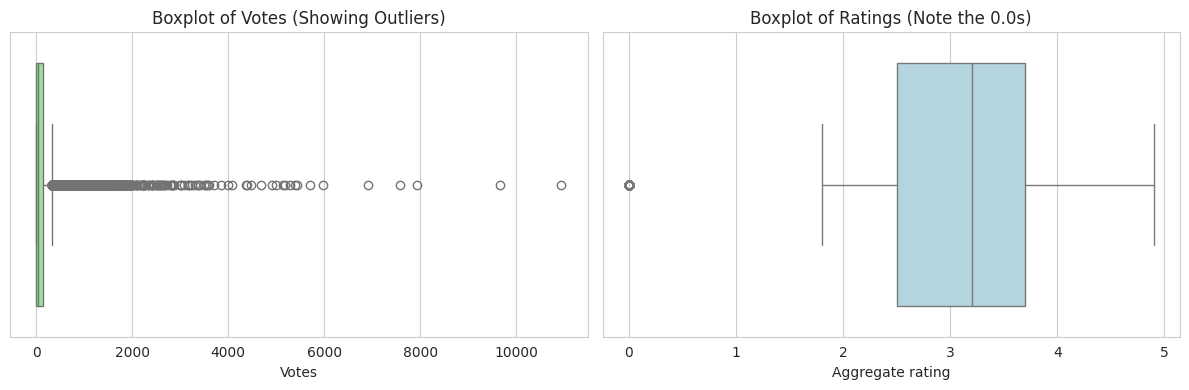

In [57]:
# --- Visualizing Outliers with Boxplots ---
plt.figure(figsize=(12, 4))

# Boxplot for Votes
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Votes'], color='lightgreen')
plt.title('Boxplot of Votes (Showing Outliers)')

# Boxplot for Ratings
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Aggregate rating'], color='lightblue')
plt.title('Boxplot of Ratings (Note the 0.0s)')

plt.tight_layout()
plt.show()

## Internship TASK: Level 1

### Task1: Top Cuisines

In [58]:
all_cuisines = df_clean['Cuisines'].str.split(',').explode().str.strip()
top_3_cuisines = all_cuisines.value_counts().head(3)
total_restaurants = len(df_clean)
cuisine_percentages = (top_3_cuisines / total_restaurants) * 100

print("\n1. Top 3 Cuisines:")
print(top_3_cuisines)
print("\nPercentage of restaurants serving them:")
print(cuisine_percentages)


1. Top 3 Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Percentage of restaurants serving them:
Cuisines
North Indian    41.500734
Chinese         28.662754
Fast Food       20.813247
Name: count, dtype: float64


### Task2: City Analysis

In [59]:
top_city = df_clean['City'].value_counts().idxmax()
top_city_count = df_clean['City'].value_counts().max()
print(f"\n2.City with the most restaurants: {top_city} ({top_city_count} restaurants)")

highest_rating_city = df_clean.groupby('City')['Aggregate rating'].mean().idxmax()
highest_rating_val = df_clean.groupby('City')['Aggregate rating'].mean().max()
print(f"City with highest average rating: {highest_rating_city} ({highest_rating_val:.2f})")


2.City with the most restaurants: New Delhi (5473 restaurants)
City with highest average rating: Inner City (4.90)


### Task3: Price Range Distribution

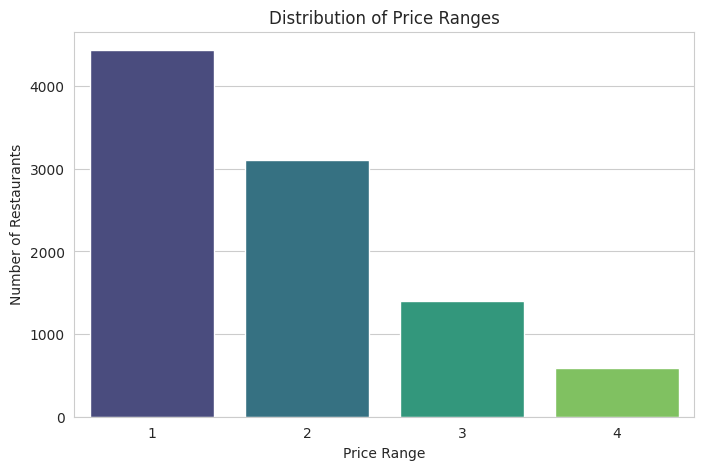


3.Percentage of restaurants in each price range:
 Price range
1    46.510166
2    32.624188
3    14.724376
4     6.141270
Name: proportion, dtype: float64


In [60]:
# Create a bar chart for Price Range
plt.figure(figsize=(8, 5))
sns.countplot(x='Price range', data=df_clean, palette='viridis')
plt.title('Distribution of Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.show()

price_percentage = df_clean['Price range'].value_counts(normalize=True) * 100
print("\n3.Percentage of restaurants in each price range:\n", price_percentage)

### Task4: Online Delivery

In [61]:
delivery_percentage = df_clean['Has Online delivery'].value_counts(normalize=True) * 100
print("\n4. Online Delivery Availability:\n", delivery_percentage)
print("\n")
avg_rating_delivery = df_clean.groupby('Has Online delivery')['Aggregate rating'].mean()
print("Average rating by online delivery status:\n", avg_rating_delivery)


4. Online Delivery Availability:
 Has Online delivery
No     74.313561
Yes    25.686439
Name: proportion, dtype: float64


Average rating by online delivery status:
 Has Online delivery
No     2.463517
Yes    3.248837
Name: Aggregate rating, dtype: float64


## Internship TASK: Level 2

### Task1: Restaurant Ratings

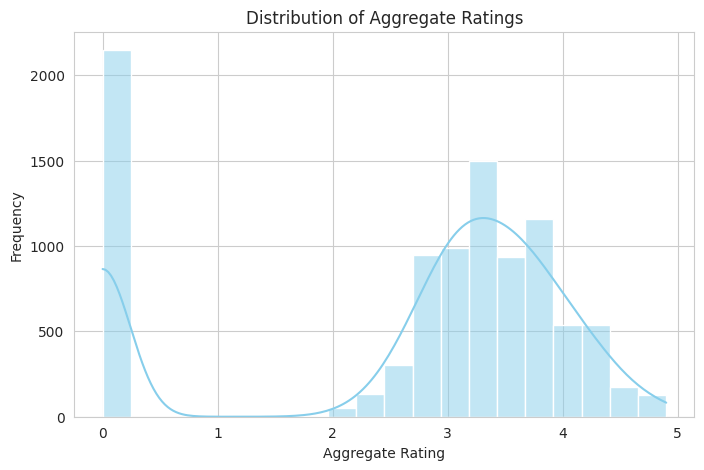


1. Most common rating range is around 2.9 to 3.9
   Average number of votes per restaurant: 156.77


In [62]:
# Plotting the distribution of ratings
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Aggregate rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

rating_bins = df_clean['Aggregate rating'].value_counts(bins=5)
print("\n1. Most common rating range is around 2.9 to 3.9")
print(f"   Average number of votes per restaurant: {df_clean['Votes'].mean():.2f}")

### Task2: Cuisine Combination

In [63]:
top_combos = df_clean['Cuisines'].value_counts().head(5)
print("\n2. Most common combinations of cuisines:")
print(top_combos)

# Average rating for combinations with at least 10 occurrences
combo_stats = df_clean.groupby('Cuisines')['Aggregate rating'].agg(['mean', 'count'])
top_rated_combos = combo_stats[combo_stats['count'] >= 10].sort_values(by='mean', ascending=False).head(5)
print("\n   Highest rated cuisine combinations (minimum 10 restaurants):")
print(top_rated_combos)


2. Most common combinations of cuisines:
Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Fast Food                354
North Indian, Mughlai    334
Name: count, dtype: int64

   Highest rated cuisine combinations (minimum 10 restaurants):
                                mean  count
Cuisines                                   
Modern Indian               4.345455     11
Indian                      4.250000     18
Seafood                     4.114286     14
Thai                        4.100000     16
Cafe, Continental, Italian  4.080000     10


### Task3: Geographic Analysis

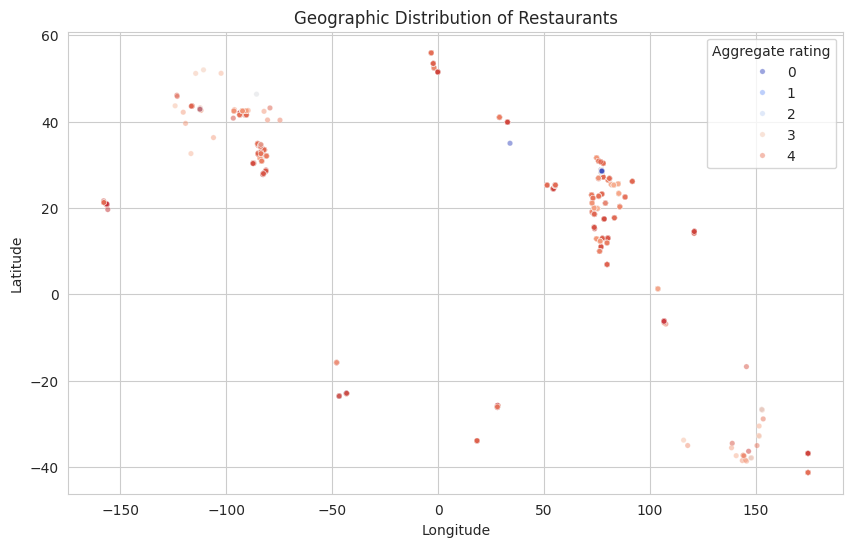


3. Geographic Analysis: Scatter plot rendered above showing restaurant clusters.


In [64]:
# Filter out 0,0 coordinates for a clean map plot
df_map = df_clean[(df_clean['Latitude'] != 0) & (df_clean['Longitude'] != 0)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', data=df_map, alpha=0.5, s=15, hue='Aggregate rating', palette='coolwarm')
plt.title('Geographic Distribution of Restaurants')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
print("\n3. Geographic Analysis: Scatter plot rendered above showing restaurant clusters.")

### Task4: Restaurant Chains

In [65]:
# A chain is defined as a restaurant name appearing more than once
chain_counts = df_clean['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1]
print(f"\n4. Number of restaurant chains identified: {len(chains)}")

# Get stats for the top 5 largest chains
top_5_chains = chains.head(5).index.tolist()
chain_stats = df_clean[df_clean['Restaurant Name'].isin(top_5_chains)].groupby('Restaurant Name').agg(
    Locations=('Restaurant Name', 'count'),
    Avg_Rating=('Aggregate rating', 'mean'),
    Total_Votes=('Votes', 'sum')
).sort_values(by='Locations', ascending=False)

print("\n   Top 5 largest chains and their performance:")
print(chain_stats)


4. Number of restaurant chains identified: 734

   Top 5 largest chains and their performance:
                  Locations  Avg_Rating  Total_Votes
Restaurant Name                                     
Cafe Coffee Day          83    2.419277         2428
Domino's Pizza           79    2.740506         6643
Subway                   63    2.907937         6124
Green Chick Chop         51    2.672549          964
McDonald's               48    3.339583         5291


## Internship TASK: Level 3

### Task1: Restaurant Reviews

In [66]:
# Analyze available text and their lengths
df_clean['Review Length'] = df_clean['Rating text'].astype(str).apply(len)
text_analysis = df_clean.groupby('Rating text').agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Text_Length=('Review Length', 'mean'),
    Count=('Restaurant ID', 'count')
).sort_values(by='Average_Rating', ascending=False)

print("\nRating Text lengths vs Average Ratings:")
print(text_analysis)


Rating Text lengths vs Average Ratings:
             Average_Rating  Text_Length  Count
Rating text                                    
Excellent          4.659667          9.0    300
Very Good          4.167904          9.0   1078
Good               3.683063          4.0   2096
Average            3.051339          7.0   3734
Poor               2.297849          4.0    186
Not rated          0.000000          9.0   2148


### Task2: Votes Analysis


2. Votes Analysis:
   Highest votes: Toit (10934 votes)
   Lowest votes: Cantinho da Gula (0 votes)
   Correlation between Votes and Rating: 0.3135 (Moderate Positive)


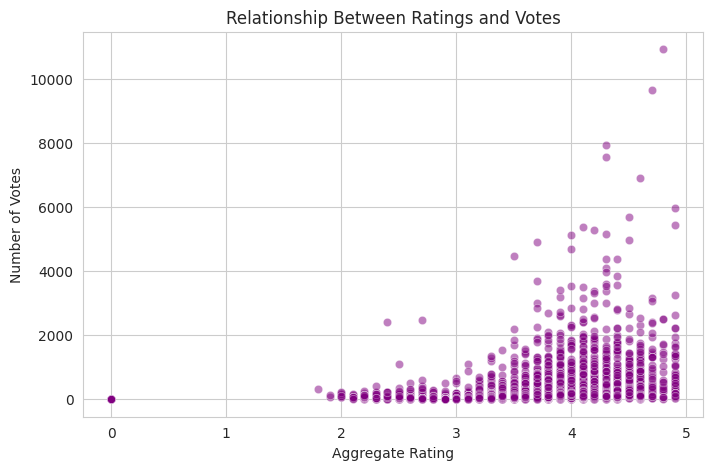

In [67]:
max_votes_idx = df_clean['Votes'].idxmax()
min_votes_idx = df_clean['Votes'].idxmin()

print("\n2. Votes Analysis:")
print(f"   Highest votes: {df_clean.loc[max_votes_idx, 'Restaurant Name']} ({df_clean.loc[max_votes_idx, 'Votes']} votes)")
print(f"   Lowest votes: {df_clean.loc[min_votes_idx, 'Restaurant Name']} ({df_clean.loc[min_votes_idx, 'Votes']} votes)")

# Calculate correlation (Pearson by default)
correlation = df_clean['Votes'].corr(df_clean['Aggregate rating'])
print(f"   Correlation between Votes and Rating: {correlation:.4f} (Moderate Positive)")

# Optional: Scatter plot to visualize the correlation
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Aggregate rating', y='Votes', data=df_clean, alpha=0.5, color='purple')
plt.title('Relationship Between Ratings and Votes')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Votes')
plt.show()

### Task3: Price Range vs. Online Delivery and Table Booking


3. Price Range vs. Online Delivery and Table Booking:
             % Offering Delivery  % Offering Table Booking
Price range                                               
1                      15.795403                  0.022533
2                      41.310633                  7.677482
3                      29.252669                 45.836299
4                       9.044369                 46.757679


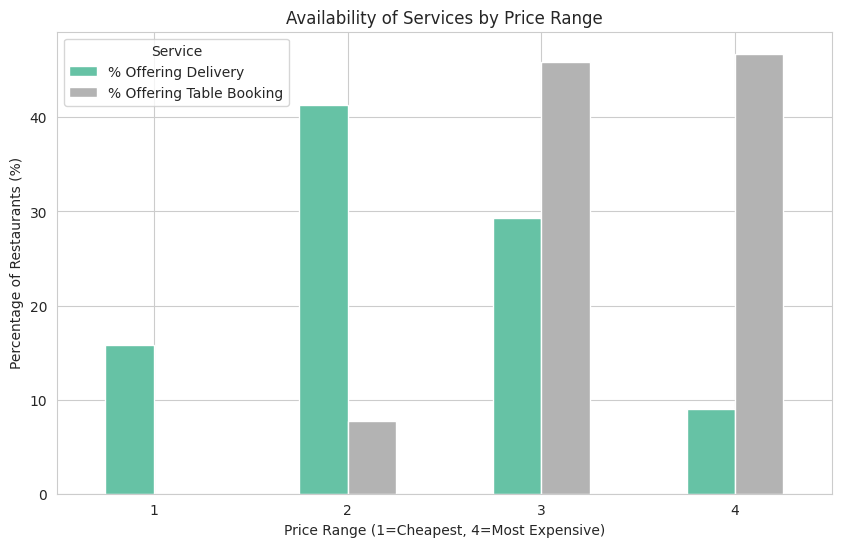

In [68]:
print("\n3. Price Range vs. Online Delivery and Table Booking:")

# Convert Yes/No strings to 1 and 0 to easily calculate percentages
df_clean['Delivery_Num'] = df_clean['Has Online delivery'].map({'Yes': 1, 'No': 0})
df_clean['Booking_Num'] = df_clean['Has Table booking'].map({'Yes': 1, 'No': 0})

# Group by price range and calculate the mean (which gives the percentage when multiplied by 100)
service_analysis = df_clean.groupby('Price range')[['Delivery_Num', 'Booking_Num']].mean() * 100
service_analysis.columns = ['% Offering Delivery', '% Offering Table Booking']

print(service_analysis)

# Visualize this relationship
service_analysis.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Availability of Services by Price Range')
plt.xlabel('Price Range (1=Cheapest, 4=Most Expensive)')
plt.ylabel('Percentage of Restaurants (%)')
plt.xticks(rotation=0)
plt.legend(title="Service")
plt.show()